# 2. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio utiliza exclusivamente DEVELOPMENT, del 11 de agosto de 2020 a las 06:00 UTC al 1 de julio de 2025 a las 18:00 UTC. TEST permanece reservado desde la partición cronológica inicial. Los resultados describen los datos disponibles para desarrollar el modelo; no se entrenan modelos ni se evalúa el conjunto de prueba.

Las decisiones posteriores de imputación, transformación, escalado, selección de variables o tratamiento de extremos deberán ajustarse únicamente con la porción de entrenamiento de cada partición temporal. Las estadísticas globales de DEVELOPMENT que se presentan aquí son descriptivas y no constituyen parámetros de preprocesamiento para validación.

## 2.1 Análisis de la variable objetivo

### Definición y disponibilidad temporal

La variable objetivo es la **volatilidad realizada futura a 24 horas**, una magnitud cuantitativa continua. Por tratarse de regresión, las frecuencias por clase, el desbalance de clases y el tamaño de la clase minoritaria no aplican.

Sea $C_{i,t}$ el precio de cierre de la vela horaria $t$ del activo $i$. Se define el retorno logarítmico como $r_{i,t}=\ln(C_{i,t}/C_{i,t-1})$ y el objetivo como:

$$
y_{i,t}=100\sqrt{\sum_{j=1}^{24}r_{i,t+j}^{2}}.
$$

La raíz de la suma de retornos intradía al cuadrado mide la volatilidad realizada durante el horizonte. La construcción se enmarca en la metodología de [Andersen, Bollerslev, Diebold y Labys (2003)](https://doi.org/10.1111/1468-0262.00418). En este proyecto se utilizan 24 retornos horarios: el resultado se expresa en porcentaje, no se anualiza y no se divide entre 24. No equivale a la desviación estándar muestral de los retornos ni se presenta como una medida sin error de la volatilidad latente.

El índice $t$ identifica la vela por su hora de apertura, pero la predicción se plantea **después de su cierre y una vez que sus datos estén disponibles**. El objetivo usa los cierres desde $C_{i,t}$ hasta $C_{i,t+24}$; su valor solo se conoce al terminar las 24 horas futuras. Por ejemplo, una vela con apertura a las 10:00 permite plantear el pronóstico después de su cierre, alrededor de las 11:00, no a las 10:00. Las variables explicativas deben corresponder a esa vela cerrada o a información anterior.

### Ventanas válidas y cobertura

Se exige una secuencia de 25 cierres horarios consecutivos para calcular los 24 retornos. Cada cierre debe corresponder al último milisegundo de su hora, según la regla de consistencia definida en 1.7.6. Las ventanas que incluyen horas ausentes o alguno de los 28 cierres no convencionales quedan sin objetivo en esta definición conservadora. Esta exclusión afecta a la tabla derivada, no elimina filas del dataset original ni declara erróneas las velas señaladas.

También se excluyen las últimas 24 horas de referencia de DEVELOPMENT, porque su horizonte futuro sobrepasa la partición. No se consultan datos de TEST para completarlo. Los motivos se contabilizan de forma excluyente: primero límite temporal, después horas ausentes y finalmente cierres irregulares.

| Activo | Velas observadas | Objetivos válidos | Borde final | Huecos | Cierres irregulares |
| --- | ---: | ---: | ---: | ---: | ---: |
| BTCUSDT | 42,833 | 42,539 | 24 | 240 | 30 |
| ETHUSDT | 42,833 | 42,539 | 24 | 240 | 30 |
| BNBUSDT | 42,833 | 42,539 | 24 | 240 | 30 |
| XRPUSDT | 42,833 | 42,564 | 24 | 240 | 5 |
| SOLUSDT | 42,833 | 42,564 | 24 | 240 | 5 |

En total se obtienen **212,745 objetivos válidos**; 1,420 velas de referencia quedan sin objetivo: 120 por el borde final, 1,200 por huecos y 100 adicionales por cierres irregulares. Una misma vela irregular afecta a varias ventanas solapadas.

Como sensibilidad, aceptar cierres irregulares manteniendo las demás condiciones produciría 42,569 objetivos por activo. Frente a la definición conservadora, añadiría 30 ventanas en BTC, ETH y BNB, y 5 en XRP y SOL. El cambio absoluto en la media es inferior a 0.0006 puntos porcentuales por activo y los máximos no cambian. Esta comparación no prueba la validez de los cierres irregulares; se mantiene la definición conservadora. Los resultados completos están en la [tabla de sensibilidad](../outputs/tables/eda_target_sensitivity.csv).

### Distribución, asimetría y valores extremos

| Activo | Mínimo (%) | Mediana (%) | Media (%) | P95 (%) | P99 (%) | Máximo (%) |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| BTCUSDT | 0.2192 | 2.4239 | 2.7522 | 5.9095 | 8.8148 | 16.5971 |
| ETHUSDT | 0.2659 | 3.0945 | 3.5639 | 7.5489 | 12.0423 | 25.1058 |
| BNBUSDT | 0.3879 | 2.7903 | 3.4342 | 7.9181 | 13.6605 | 29.7777 |
| XRPUSDT | 0.5611 | 3.3650 | 4.3678 | 10.9599 | 18.6078 | 39.0647 |
| SOLUSDT | 0.9167 | 4.7852 | 5.6996 | 12.3089 | 19.6207 | 34.6655 |

No se observan objetivos iguales a cero. SOL presenta la mayor mediana (4.7852%) y BTC la menor (2.4239%). XRP alcanza el máximo más alto (39.0647%), aunque su mediana es inferior a la de SOL. Por ello, el nivel habitual de volatilidad y la intensidad de los episodios extremos deben distinguirse. Los cuartiles y la desviación estándar están en el [resumen completo](../outputs/tables/eda_target_summary.csv).



| Activo | Asimetría | Exceso de curtosis | Señalados por IQR | Porcentaje |
| --- | ---: | ---: | ---: | ---: |
| BTCUSDT | 2.000 | 7.101 | 2,058 | 4.84% |
| ETHUSDT | 2.208 | 8.878 | 1,965 | 4.62% |
| BNBUSDT | 3.225 | 17.727 | 2,429 | 5.71% |
| XRPUSDT | 3.171 | 15.266 | 3,261 | 7.66% |
| SOLUSDT | 2.607 | 11.012 | 2,246 | 5.28% |

La asimetría es positiva en todos los activos y la media supera la mediana. Los excesos de curtosis positivos, entre 7.101 y 17.727, y los valores extremos visibles indican colas empíricas pronunciadas frente a una referencia normal. Estas estadísticas no demuestran una ley de colas específica ni prueban normalidad o independencia. BNB y XRP presentan los mayores excesos de curtosis; XRP también tiene la mayor proporción señalada por IQR.

Los valores fuera de las cercas $Q_1-1.5\,IQR$ y $Q_3+1.5\,IQR$ son candidatos a extremos, no errores demostrados. Se conservan todos los objetivos válidos, incluidos los elevados. El IQR no se utiliza aquí para recortar ni winsorizar la variable objetivo.

### Necesidad de transformación

El logaritmo permite examinar si la escala positiva y la asimetría del objetivo se representan de forma más equilibrada. La tabla compara la asimetría y el exceso de curtosis antes y después del logaritmo, únicamente como diagnóstico.

| Activo | Asimetría original | Asimetría de ln(y) | Exceso de curtosis original | Exceso de curtosis de ln(y) |
| --- | ---: | ---: | ---: | ---: |
| BTCUSDT | 2.000 | -0.280 | 7.101 | 0.564 |
| ETHUSDT | 2.208 | -0.138 | 8.878 | 0.425 |
| BNBUSDT | 3.225 | 0.176 | 17.727 | 0.259 |
| XRPUSDT | 3.171 | 0.454 | 15.266 | 0.358 |
| SOLUSDT | 2.607 | 0.304 | 11.012 | 0.280 |

Una menor asimetría no demuestra normalidad ni garantiza mejores pronósticos. No se adopta una transformación definitiva. Box–Cox es una alternativa para valores estrictamente positivos, pero su parámetro no se estima globalmente en esta etapa: si se evalúa posteriormente, deberá ajustarse dentro de cada partición de entrenamiento. Lo mismo aplica a cualquier desplazamiento utilizado si aparecen ceros en datos futuros.

Si se modelara el logaritmo del objetivo, minimizar el error en esa escala cambiaría la importancia relativa de los errores grandes y pequeños. Además, exponenciar un pronóstico en escala logarítmica no produce automáticamente la media condicional en la escala original. La elección deberá evaluarse cronológicamente y las métricas finales deberán incluir la escala original.

### Comportamiento temporal



| Activo | Apertura de referencia (UTC) | Máximo (%) |
| --- | ---: | ---: |
| BTCUSDT | 2021-05-19 00:00 | 16.5971 |
| ETHUSDT | 2021-05-19 09:00 | 25.1058 |
| BNBUSDT | 2021-05-19 02:00 | 29.7777 |
| XRPUSDT | 2021-02-01 02:00 | 39.0647 |
| SOLUSDT | 2022-11-09 14:00 | 34.6655 |

Los máximos de BTC, ETH y BNB corresponden a ventanas iniciadas el 19 de mayo de 2021; los de XRP y SOL ocurren en fechas diferentes. Las fechas identifican ventanas futuras de 24 horas y no un único retorno ni una causa económica comprobada. La evolución muestra episodios de distinta intensidad, lo que exige evaluar el desempeño en varios bloques cronológicos.

| Activo | Correlación del objetivo a 1h | Correlación del objetivo a 24h |
| --- | ---: | ---: |
| BTCUSDT | 0.990 | 0.595 |
| ETHUSDT | 0.991 | 0.650 |
| BNBUSDT | 0.994 | 0.711 |
| XRPUSDT | 0.991 | 0.625 |
| SOLUSDT | 0.992 | 0.689 |

Las correlaciones se calculan por pares disponibles sobre la cuadrícula horaria, sin comprimir los huecos. La elevada asociación a una hora está influida mecánicamente por el solapamiento de 23 retornos entre etiquetas. A 24 horas las ventanas de retornos ya no se solapan, aunque persiste asociación descriptiva. Ninguno de estos coeficientes sustituye una evaluación fuera de muestra.

No se realiza análisis espacial: el dataset carece de coordenadas geográficas. Los activos son entidades del panel y no ubicaciones espaciales.

### Relación con las variables explicativas disponibles

Como exploración inicial vinculada al análisis bivariado, se compara el objetivo con las nueve variables numéricas de la vela cerrada, el retorno de esa hora y la volatilidad realizada de las 24 horas anteriores, definida como $100\sqrt{\sum_{j=0}^{23}r_{i,t-j}^{2}}$. Esta última usa exclusivamente información pasada y se calcula con la misma regla de continuidad y cierres convencionales. No se ejecuta el baseline Persistence ni se evalúa un pronóstico.

Las fechas actúan como índices temporales y `symbol` identifica el activo. No se asignan códigos numéricos arbitrarios a los símbolos para calcular correlaciones. Las asociaciones se calculan por activo y con los pares disponibles para cada variable; por eso su tamaño de muestra puede variar. Las cifras completas se incluyen en la [tabla de correlaciones y tamaños de muestra](../outputs/tables/eda_target_correlations.csv).





La volatilidad pasada de 24 horas muestra correlaciones de Pearson entre 0.595 y 0.711 con el objetivo, y de Spearman entre 0.579 y 0.697. Sus retornos no se solapan con los del objetivo futuro, aunque ambas ventanas comparten el cierre que actúa como frontera. Esta asociación motiva estudiar la persistencia más adelante, sin afirmar todavía el desempeño del baseline.

El volumen en USDT presenta asociaciones distintas según el activo: Spearman es 0.384 para BTC, 0.503 para ETH, 0.529 para BNB, 0.562 para XRP y 0.029 para SOL. Los volúmenes taker presentan patrones similares a sus volúmenes totales. El número de operaciones también varía: Spearman va de 0.006 en SOL a 0.539 en XRP.

Los cuatro precios OHLC muestran asociaciones parecidas dentro de cada activo y más débiles en valor absoluto que la volatilidad pasada. El retorno horario con signo tiene una correlación de Pearson cercana a cero en los cinco activos (entre -0.040 y 0.003); esto no descarta relaciones no lineales ni una posible relación con su magnitud absoluta. Los diagramas de densidad permiten observar dispersión y extremos que un coeficiente aislado no describe.

Estos resultados no constituyen una selección definitiva de predictores ni un análisis multivariado condicional. Las asociaciones con precios y volúmenes pueden depender del periodo y de cambios de régimen; una correlación no implica causalidad ni capacidad predictiva fuera de muestra. La selección y las transformaciones deberán contrastarse después mediante validación temporal, sin TEST.

### Implicaciones para métricas y validación

Se propone reportar MAE y RMSE en puntos porcentuales de volatilidad, por activo y como promedio de las métricas de los cinco activos con igual ponderación. MAE describe el tamaño absoluto del error y RMSE da mayor peso a errores grandes, por lo que su lectura conjunta permite examinar el desempeño durante episodios de alta volatilidad. No se reportan valores de estas métricas porque todavía no se han generado pronósticos. Los errores porcentuales relativos requieren cautela cuando el objetivo se aproxima a cero.

La validación deberá ser cronológica, con ventanas de entrenamiento anteriores a las de validación, y mantener todos los activos de una misma fecha en el mismo bloque temporal. No se utilizará una partición aleatoria de filas. La [documentación de validación temporal de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) describe la separación ordenada y el uso de un intervalo entre entrenamiento y evaluación; en este panel, ese intervalo debe aplicarse a timestamps globales, no a un número de filas mezcladas entre activos.

Los objetivos de horas consecutivas comparten 23 de sus 24 retornos. Por ello, la dependencia entre etiquetas no puede interpretarse como evidencia automática de capacidad predictiva y el número de filas no equivale a observaciones independientes. En cada frontera se excluirán del entrenamiento las etiquetas cuyo horizonte alcance el inicio de la validación: una separación conservadora de 24 horas entre las horas de referencia evita el solapamiento de retornos futuros. Además, toda etiqueta de entrenamiento debe estar disponible antes de realizar la primera predicción de validación. Las ventanas se comprobarán por tiempo real, especialmente alrededor de huecos.

Todos los parámetros aprendidos de los datos deberán ajustarse de nuevo dentro de cada entrenamiento. TEST se mantendrá reservado para la evaluación final del procedimiento ya fijado.

### Reproducibilidad

El cálculo está en `src/08_eda_target_development.py`. Los resultados, cobertura, sensibilidad y trazabilidad se guardan en `outputs/tables/eda_target_*.csv` y `outputs/tables/eda_target_metadata.json`. La tabla derivada se guarda separadamente en `outputs/tables/eda_target_development_derived.csv`: no se modifica el CSV maestro ni las particiones. Se verifica cada objetivo válido contra una suma directa de 24 retornos y se comprueba la conservación de DEVELOPMENT mediante SHA-256.


In [1]:
"""EDA 2.1: volatilidad futura a 24h; solo DEVELOPMENT, sin modelos."""
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/splits/development_80.csv').is_file())
SOURCE = ROOT / 'data/splits/development_80.csv'
TABLES = ROOT / 'outputs/tables'
FIGURES = ROOT / 'book/_static/figures'
SYMBOLS = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'SOLUSDT']
FIELDS = ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume',
          'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume']


def forward_count(mask):
    """Número de cierres válidos desde t hasta t+24, ambos inclusive."""
    return mask.astype(int).rolling(25, min_periods=25).sum().shift(-24)


def main():
    fingerprint = hashlib.sha256(SOURCE.read_bytes()).hexdigest()
    df = pd.read_csv(SOURCE)
    for col in ['open_time', 'close_time']:
        df[col] = pd.to_datetime(df[col], format='ISO8601', utc=True)
    assert len(df) == 214165 and set(df.symbol) == set(SYMBOLS)
    assert not df.duplicated(['symbol', 'open_time']).any()
    start, end = pd.Timestamp('2020-08-11 06:00', tz='UTC'), pd.Timestamp('2025-07-01 18:00', tz='UTC')
    assert df.open_time.between(start, end).all()
    assert (df.close > 0).all() and np.isfinite(df[FIELDS].to_numpy()).all()
    calendar = pd.date_range(start, end, freq='h', name='open_time')
    groups, summaries, counts, correlations, extremes, sensitivity = {}, [], [], [], [], []
    output = []
    for symbol in SYMBOLS:
        g = df.loc[df.symbol.eq(symbol)].set_index('open_time').sort_index().reindex(calendar)
        observed = g.close.notna()
        conventional = g.close_time.eq(g.index + pd.Timedelta(hours=1)-pd.Timedelta(milliseconds=1))
        valid_close = observed & conventional
        # Retornos en la cuadrícula horaria: los huecos y cierres irregulares dan NaN.
        log_close = np.log(g.close.where(valid_close))
        r = log_close.diff()
        y = 100*np.sqrt(r.pow(2).rolling(24, min_periods=24).sum().shift(-24))
        y = y.where(forward_count(valid_close).eq(25))
        edge = pd.Series(g.index+pd.Timedelta(hours=24) > end, index=g.index)
        holes = ~edge & forward_count(observed).lt(25)
        irregular = ~edge & ~holes & forward_count(valid_close).lt(25)
        usable = observed & y.notna()
        assert int(observed.sum()) == int((observed & edge).sum() + (observed & holes).sum() + (observed & irregular).sum() + usable.sum())
        # Verificación directa de cada ventana válida: ni desalineación ni futuro fuera de DEVELOPMENT.
        windows = np.lib.stride_tricks.sliding_window_view(g.close.to_numpy(), 25)
        expected = 100*np.sqrt(np.square(np.diff(np.log(windows), axis=1)).sum(axis=1))
        selected = usable.iloc[:-24].to_numpy()
        assert np.allclose(y.iloc[:-24].to_numpy()[selected], expected[selected], rtol=1e-11, atol=1e-11)
        assert not usable.iloc[-24:].any()
        assert (g.index[usable]+pd.Timedelta(hours=24) <= end).all()
        g['rv_future_24h_pct'] = y
        g['return_1h_pct'] = 100*r
        g['rv_past_24h_pct'] = 100*np.sqrt(r.pow(2).rolling(24, min_periods=24).sum())
        groups[symbol] = g
        x = y.dropna()
        q1, q3 = x.quantile([.25,.75])
        lower, upper = q1-1.5*(q3-q1), q3+1.5*(q3-q1)
        flag = (x<lower) | (x>upper)
        summaries.append(dict(symbol=symbol, n=len(x), min=x.min(), q1=q1, median=x.median(),
                              mean=x.mean(), q3=q3, p95=x.quantile(.95), p99=x.quantile(.99), max=x.max(),
                              std=x.std(), skew=x.skew(), excess_kurtosis=x.kurt(),
                              zero=int(x.eq(0).sum()), lower=lower, upper=upper,
                              iqr_flagged=int(flag.sum()), iqr_percent=100*flag.mean(),
                              log_skew=np.log(x[x>0]).skew(), log_excess_kurtosis=np.log(x[x>0]).kurt(),
                              acf_1h=y.corr(y.shift(1)), acf_24h=y.corr(y.shift(24))))
        counts.append(dict(symbol=symbol, observed=int(observed.sum()), valid=int(usable.sum()),
                           boundary=int((observed & edge).sum()), missing_window=int((observed & holes).sum()),
                           irregular_window=int((observed & irregular).sum())))
        # Sensibilidad descriptiva: aceptar cierres irregulares, manteniendo huecos y borde.
        loose = 100*np.sqrt(np.log(g.close).diff().pow(2).rolling(24, min_periods=24).sum().shift(-24))
        sensitivity.append(dict(symbol=symbol, strict_n=len(x), relaxed_n=int(loose.notna().sum()),
                                strict_mean=x.mean(), relaxed_mean=loose.mean(), strict_p99=x.quantile(.99),
                                relaxed_p99=loose.quantile(.99), strict_max=x.max(), relaxed_max=loose.max()))
        for field in FIELDS + ['return_1h_pct', 'rv_past_24h_pct']:
            pair = g[[field, 'rv_future_24h_pct']].dropna()
            correlations.append(dict(symbol=symbol, predictor=field, n=len(pair),
                                      pearson=pair.iloc[:,0].corr(pair.iloc[:,1]),
                                      spearman=pair.iloc[:,0].corr(pair.iloc[:,1], method='spearman')))
        peak = x.idxmax()
        extremes.append(dict(symbol=symbol, anchor_open_time=peak.isoformat(),
                              prediction_time=(peak+pd.Timedelta(hours=1)).isoformat(),
                              last_future_open_time=(peak+pd.Timedelta(hours=24)).isoformat(), max=x.max()))
        rows = g.loc[observed, ['rv_future_24h_pct','rv_past_24h_pct','return_1h_pct']].copy()
        rows['symbol'] = symbol
        rows['reason'] = np.select([edge.loc[observed], holes.loc[observed], irregular.loc[observed]],
                                   ['boundary','missing_window','irregular_window'], default='valid')
        output.append(rows.reset_index())
    TABLES.mkdir(parents=True, exist_ok=True)
    FIGURES.mkdir(parents=True, exist_ok=True)
    tables = {'summary':summaries, 'coverage':counts, 'correlations':correlations,
              'extremes':extremes, 'sensitivity':sensitivity}
    for name, rows in tables.items():
        pd.DataFrame(rows).to_csv(TABLES / f'eda_target_{name}.csv', index=False)
    pd.concat(output, ignore_index=True).to_csv(TABLES / 'eda_target_development_derived.csv', index=False)
    summary = pd.DataFrame(summaries).set_index('symbol')
    plt.rcParams.update({'font.size':10})
    fig, axes = plt.subplots(5, 3, figsize=(15,16), constrained_layout=True)
    for i,symbol in enumerate(SYMBOLS):
        x = groups[symbol].rv_future_24h_pct.dropna()
        axes[i,0].hist(x, bins=70, color='#2563a6', log=True)
        axes[i,0].set_xlabel('Volatilidad futura 24h (%)')
        axes[i,0].set_ylabel('Frecuencia (log)')
        axes[i,1].boxplot(x, vert=False, whis=1.5, flierprops={'marker':'.','markersize':2,'alpha':.3})
        axes[i,1].set_yticks([])
        axes[i,1].set_xlabel('Volatilidad futura 24h (%)')
        axes[i,2].hist(np.log(x[x>0]), bins=70, color='#168575')
        axes[i,2].set_xlabel('ln(volatilidad en %) · diagnóstico')
        for ax in axes[i]: ax.set_title(symbol); ax.grid(alpha=.2)
    fig.suptitle('Variable objetivo · distribución, boxplot y logaritmo · DEVELOPMENT', fontsize=15)
    fig.savefig(FIGURES/'eda_target_distribution.png', dpi=150); plt.close(fig)
    fig, axes = plt.subplots(5, 1, figsize=(14,15), constrained_layout=True)
    for ax,symbol in zip(axes,SYMBOLS):
        y = groups[symbol].rv_future_24h_pct
        ax.plot(y.index, y, linewidth=.45, color='#2563a6')
        ax.plot(y.resample('MS').median(), linewidth=1.8, color='#c2410c', label='Mediana mensual')
        ax.set_title(symbol); ax.set_ylabel('Volatilidad 24h (%)'); ax.grid(alpha=.2); ax.legend()
    fig.suptitle('Evolución temporal · fecha de apertura de la vela de referencia (UTC)', fontsize=15)
    fig.savefig(FIGURES/'eda_target_time.png', dpi=150); plt.close(fig)
    corr = pd.DataFrame(correlations)
    fig,axes = plt.subplots(1,2,figsize=(14,8),constrained_layout=True)
    for ax,kind in zip(axes,['pearson','spearman']):
        pivot = corr.pivot(index='predictor',columns='symbol',values=kind).reindex(index=FIELDS+['return_1h_pct','rv_past_24h_pct'],columns=SYMBOLS)
        im=ax.imshow(pivot,vmin=-1,vmax=1,cmap='RdBu_r',aspect='auto')
        ax.set_xticks(range(5),SYMBOLS,rotation=40,ha='right')
        ax.set_yticks(range(len(pivot)),pivot.index)
        for row in range(len(pivot)):
            for col in range(5):
                val=pivot.iloc[row,col]
                ax.text(col,row,f'{val:.2f}',ha='center',va='center',color='white' if abs(val)>.6 else 'black',fontsize=9)
        ax.set_title(kind.capitalize())
    fig.colorbar(im,ax=axes,label='Correlación descriptiva con la volatilidad futura')
    fig.savefig(FIGURES/'eda_target_correlations.png',dpi=150);plt.close(fig)
    # Relaciones conjuntas en escala original: todos los pares, sin muestreo.
    fig,axes=plt.subplots(5,2,figsize=(13,15),constrained_layout=True)
    for i,symbol in enumerate(SYMBOLS):
        g=groups[symbol]
        for j,field in enumerate(['rv_past_24h_pct','quote_asset_volume']):
            pair=g[[field,'rv_future_24h_pct']].dropna()
            axes[i,j].hexbin(pair[field],pair.rv_future_24h_pct,gridsize=45,bins='log',mincnt=1,cmap='Blues')
            axes[i,j].set_title(symbol)
            axes[i,j].set_xlabel('Volatilidad pasada 24h (%)' if j==0 else 'Volumen actual (USDT)')
            axes[i,j].set_ylabel('Volatilidad futura 24h (%)')
    fig.suptitle('Densidad conjunta · color más oscuro: mayor número de pares',fontsize=15)
    fig.savefig(FIGURES/'eda_target_relations.png',dpi=150);plt.close(fig)
    assert fingerprint == hashlib.sha256(SOURCE.read_bytes()).hexdigest()
    (TABLES/'eda_target_metadata.json').write_text(json.dumps({
        'source':'data/splits/development_80.csv','sha256':fingerprint,
        'target':'100 * sqrt(sum(log(C[t+j]/C[t+j-1])**2 for j in 1..24))',
        'anchor':'open_time de la vela t; predicción tras su cierre',
        'conventional_close':'open_time + 1h - 1ms',
        'window':'25 cierres horarios consecutivos convencionales; sin imputación',
        'annualized':False,'models_executed':False,'test_read':False,
        'versions':{'pandas':pd.__version__,'numpy':np.__version__,'matplotlib':matplotlib.__version__}
    },ensure_ascii=False,indent=2),encoding='utf-8')
    print('COBERTURA\n',pd.DataFrame(counts).to_string(index=False))
    print('\nRESUMEN\n',summary.to_string())
    print('\nSENSIBILIDAD\n',pd.DataFrame(sensitivity).to_string(index=False))
    print('\nEXTREMOS\n',pd.DataFrame(extremes).to_string(index=False))
    return tables


if __name__ == '__main__':
    main()


COBERTURA
  symbol  observed  valid  boundary  missing_window  irregular_window
BTCUSDT     42833  42539        24             240                30
ETHUSDT     42833  42539        24             240                30
BNBUSDT     42833  42539        24             240                30
XRPUSDT     42833  42564        24             240                 5
SOLUSDT     42833  42564        24             240                 5

RESUMEN
              n       min        q1    median      mean        q3        p95        p99        max       std      skew  excess_kurtosis  zero     lower      upper  iqr_flagged  iqr_percent  log_skew  log_excess_kurtosis    acf_1h   acf_24h
symbol                                                                                                                                                                                                                                        
BTCUSDT  42539  0.219194  1.656197  2.423885  2.752185  3.374404   5.909474   8.814840 

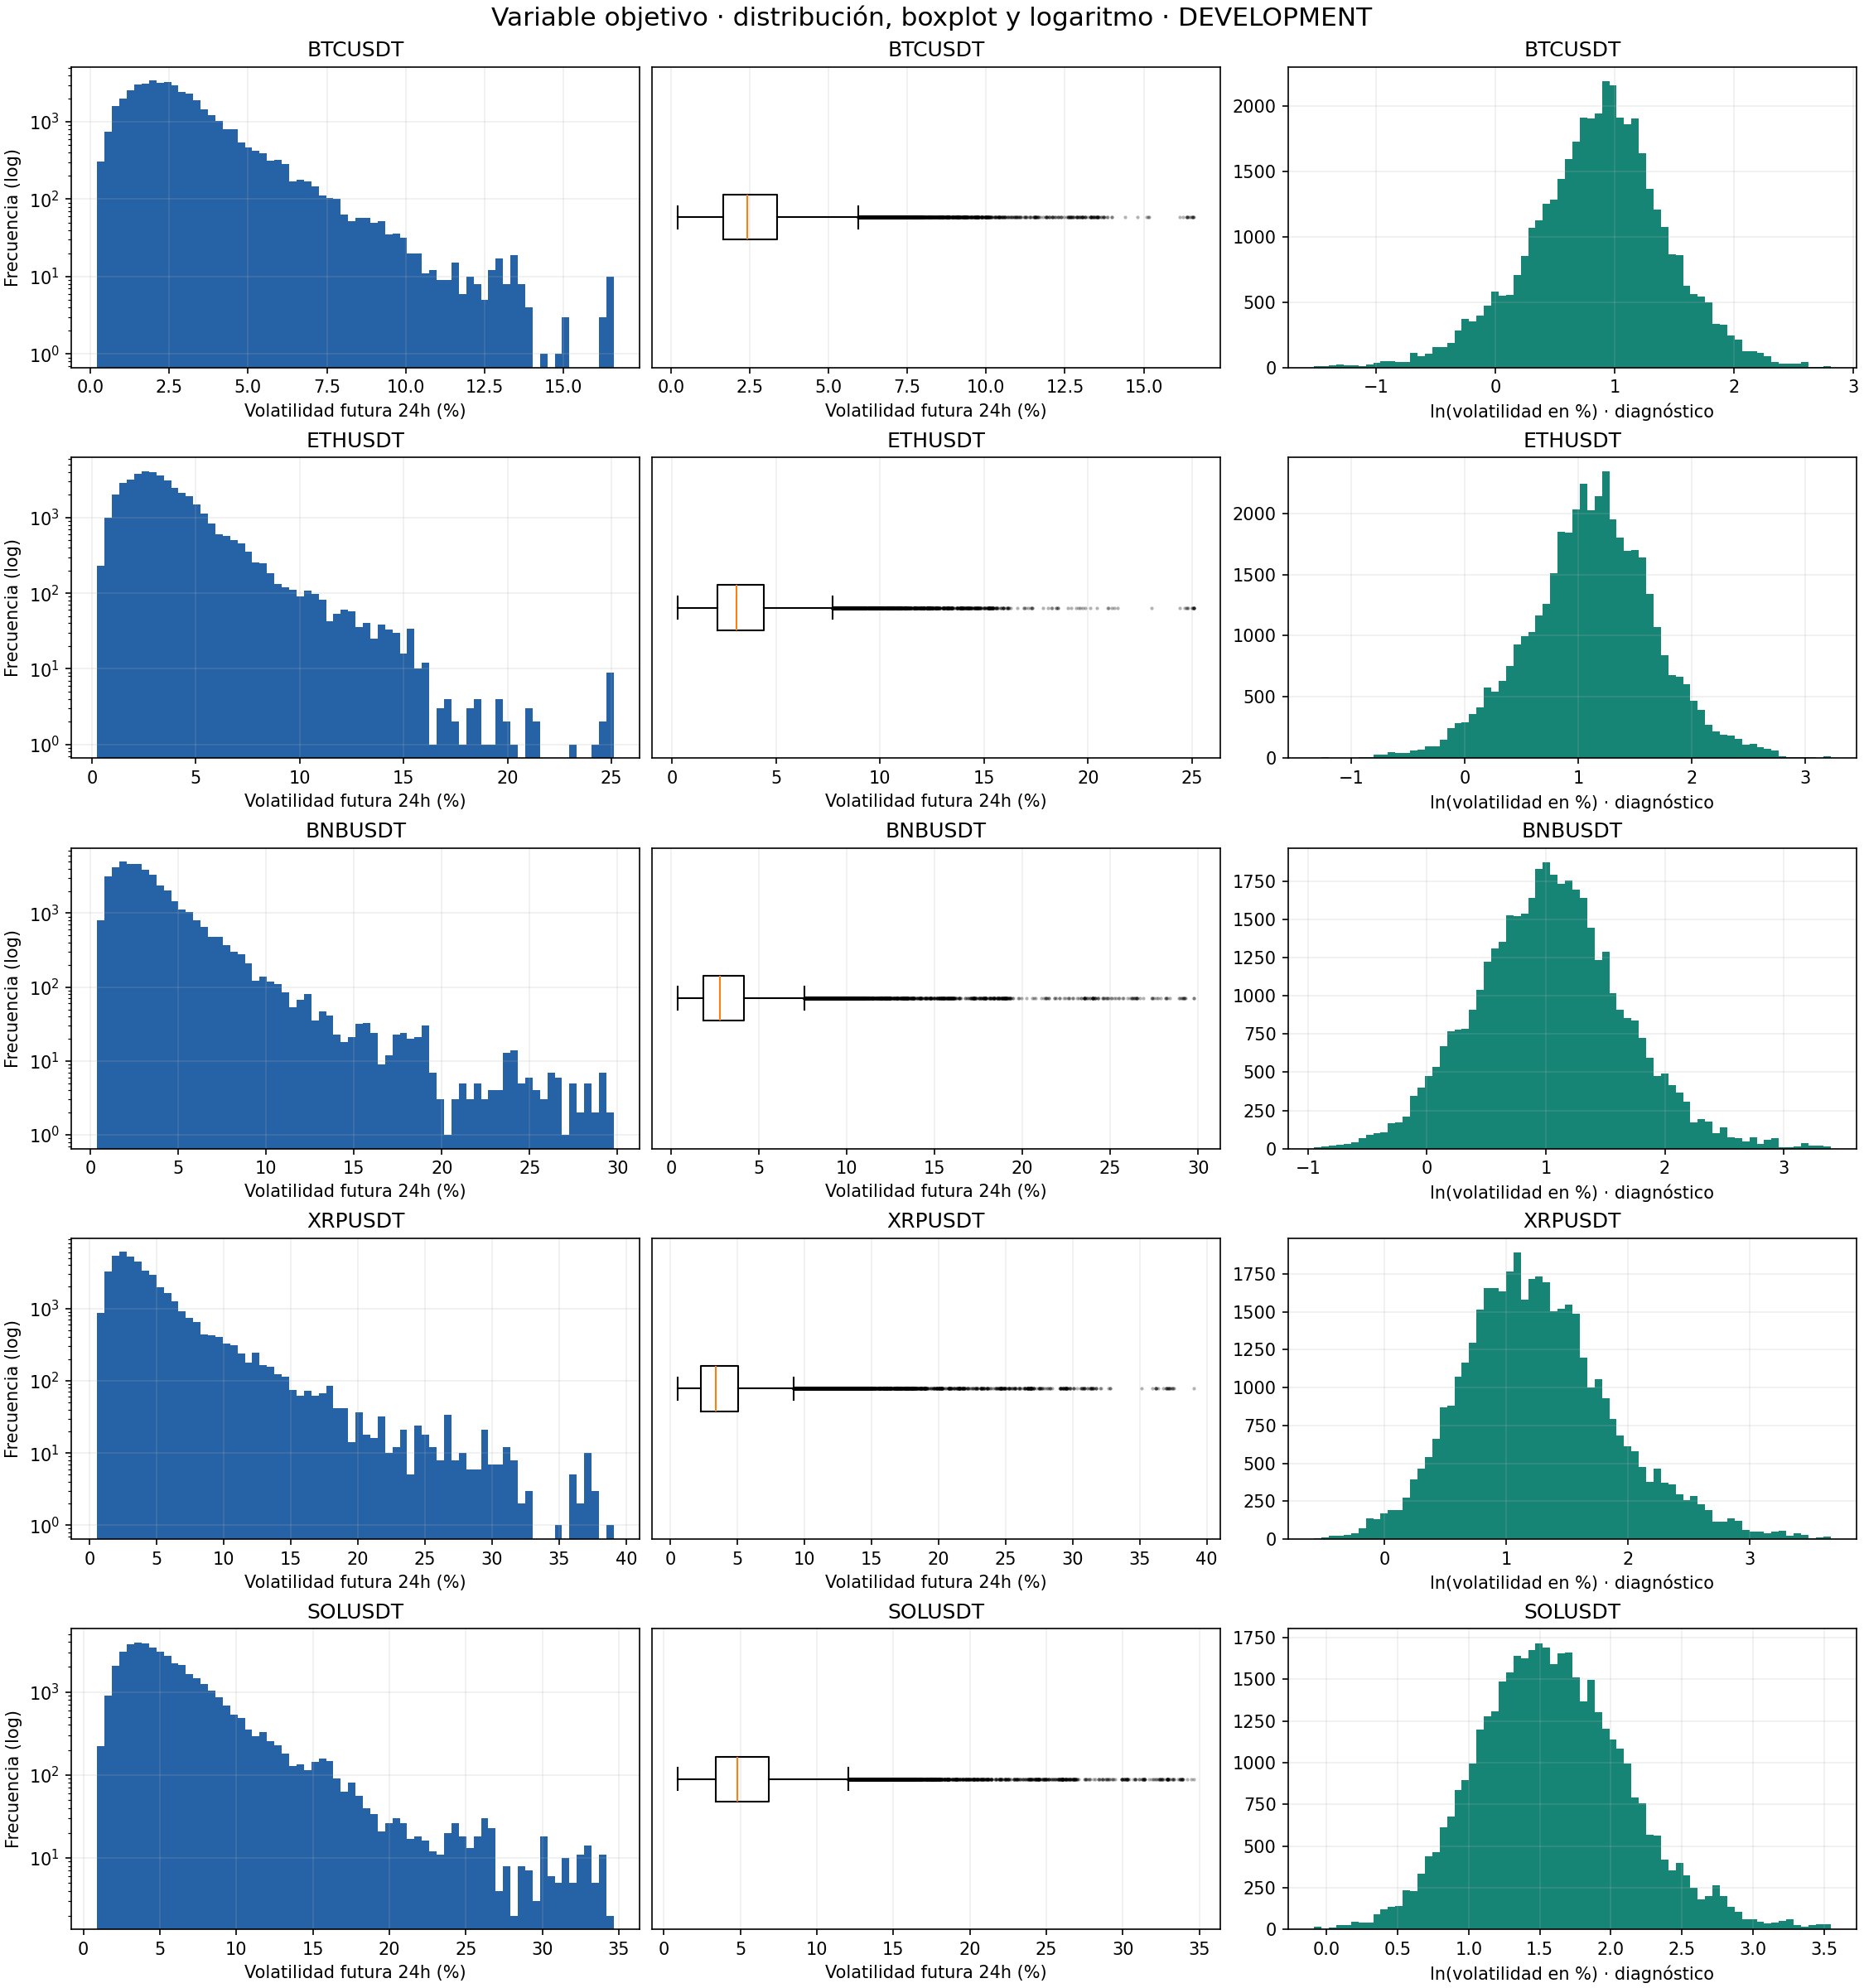

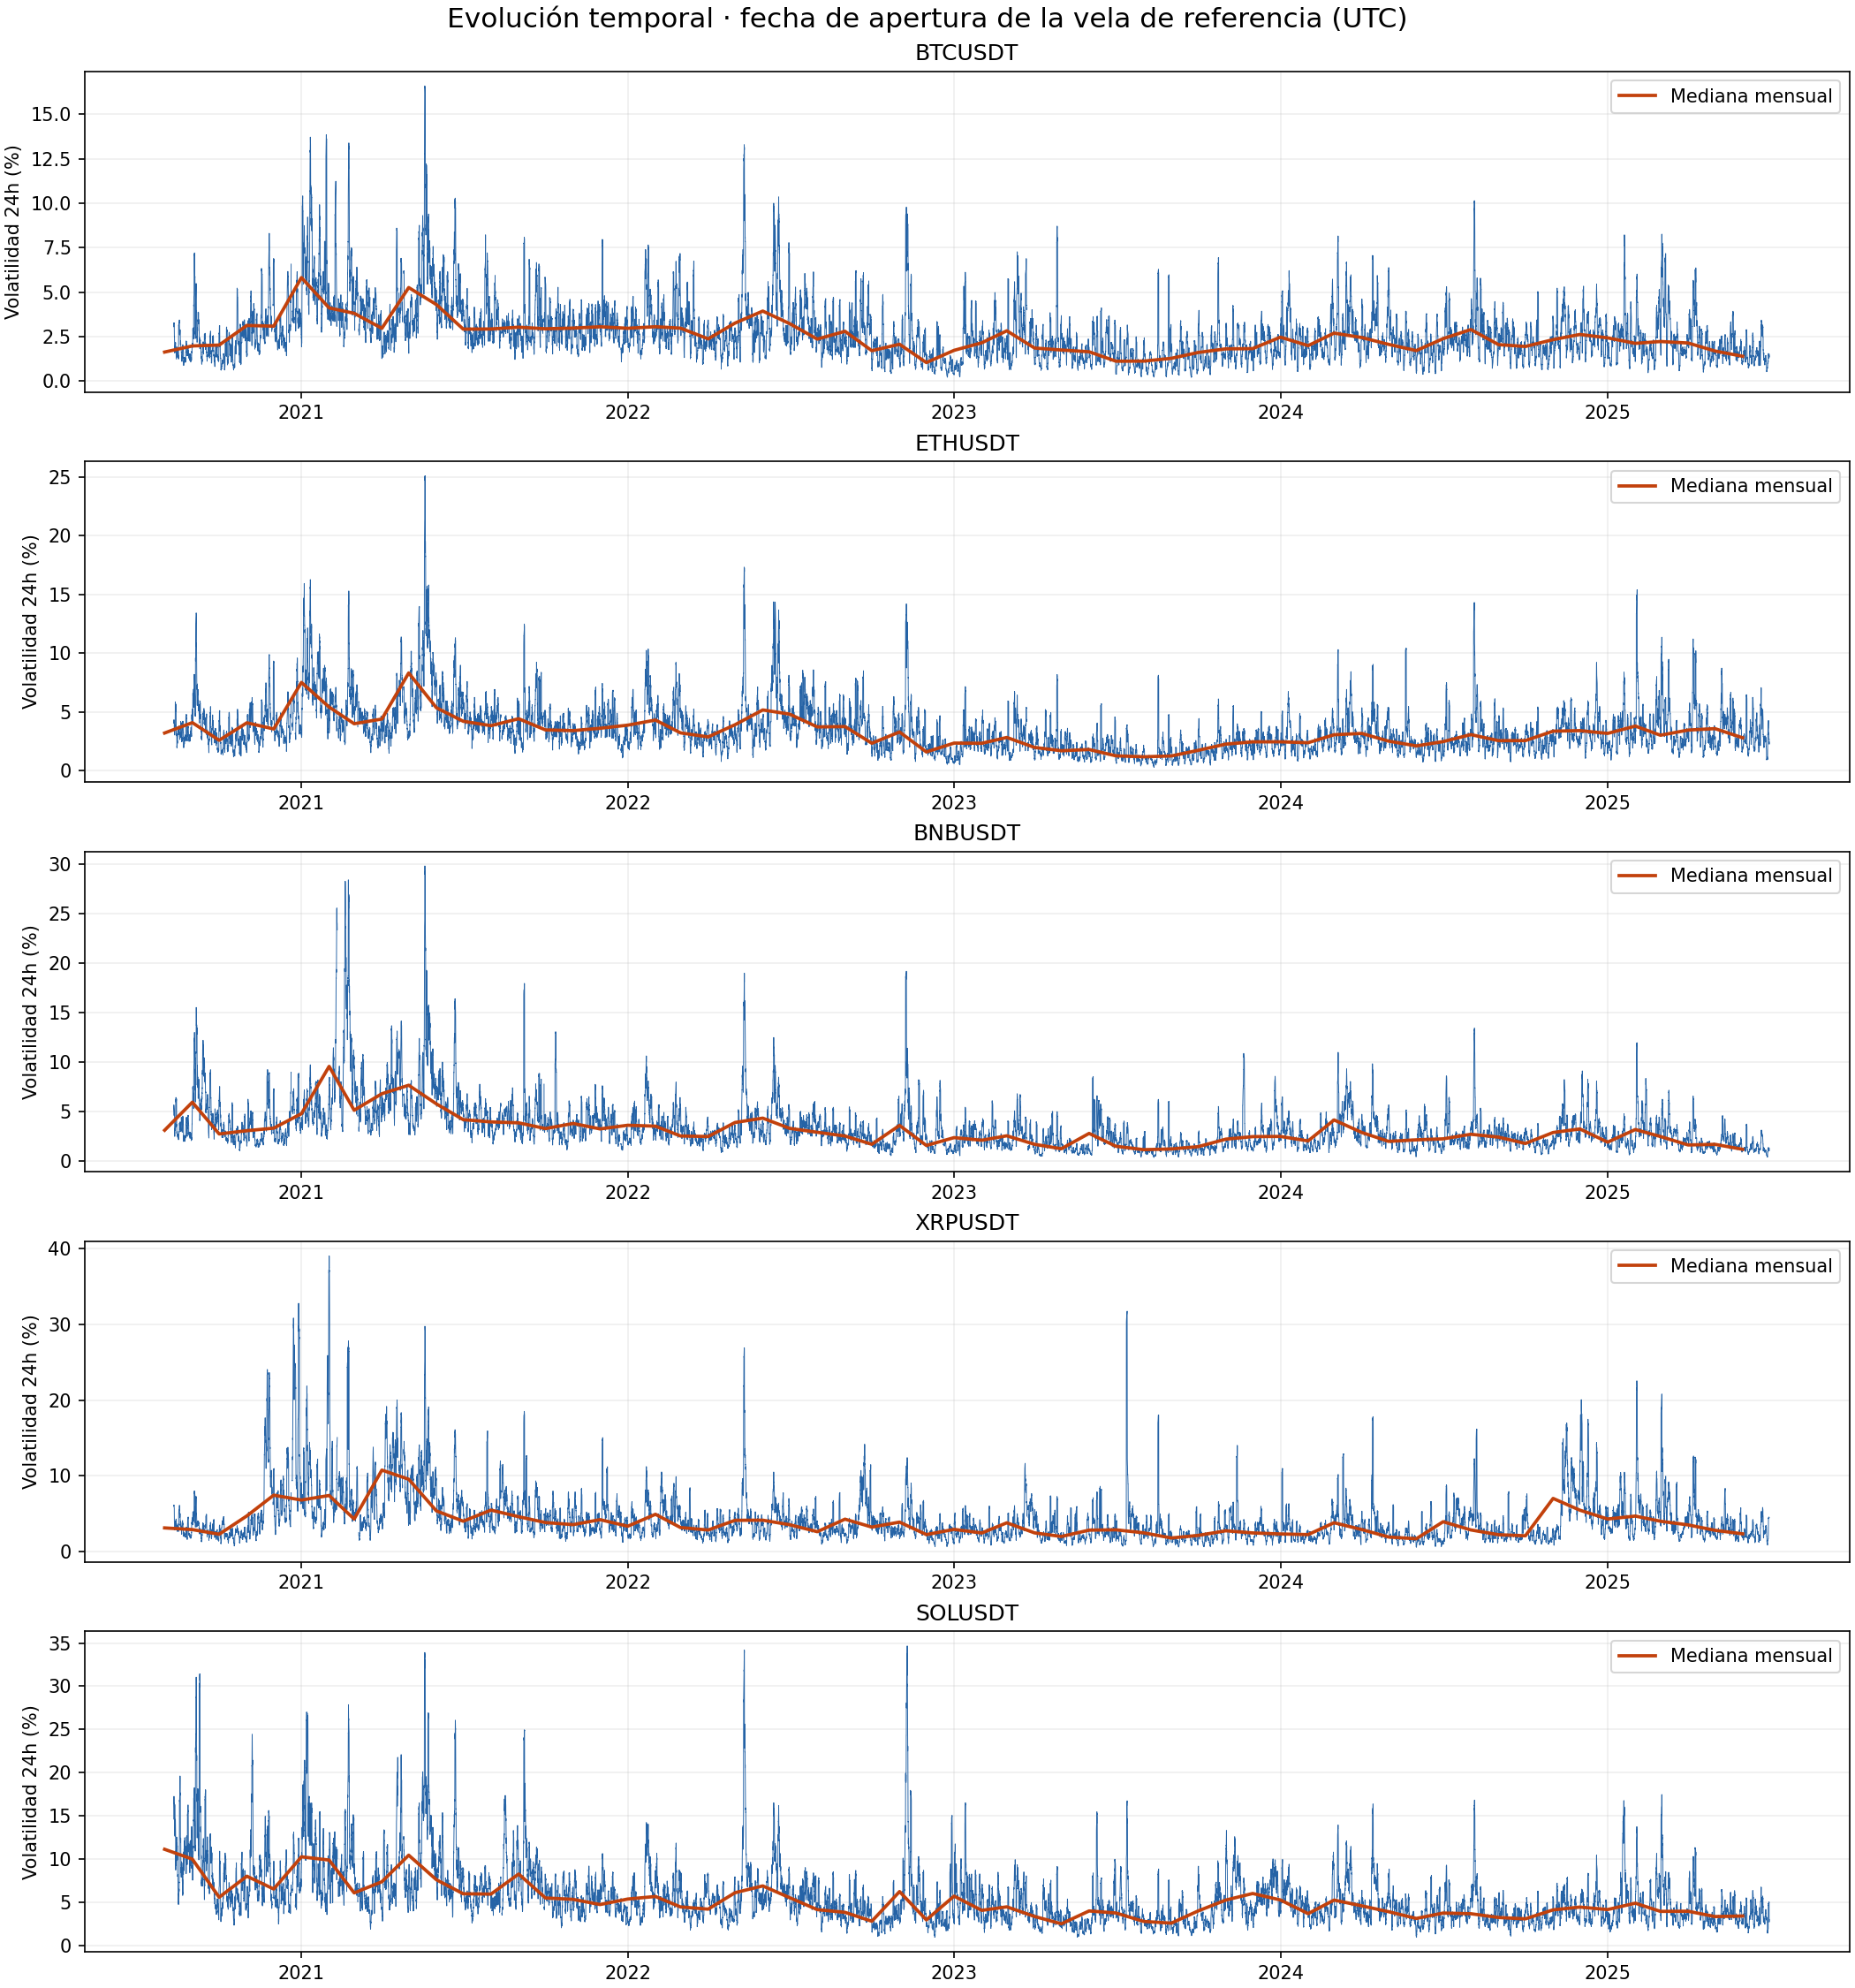

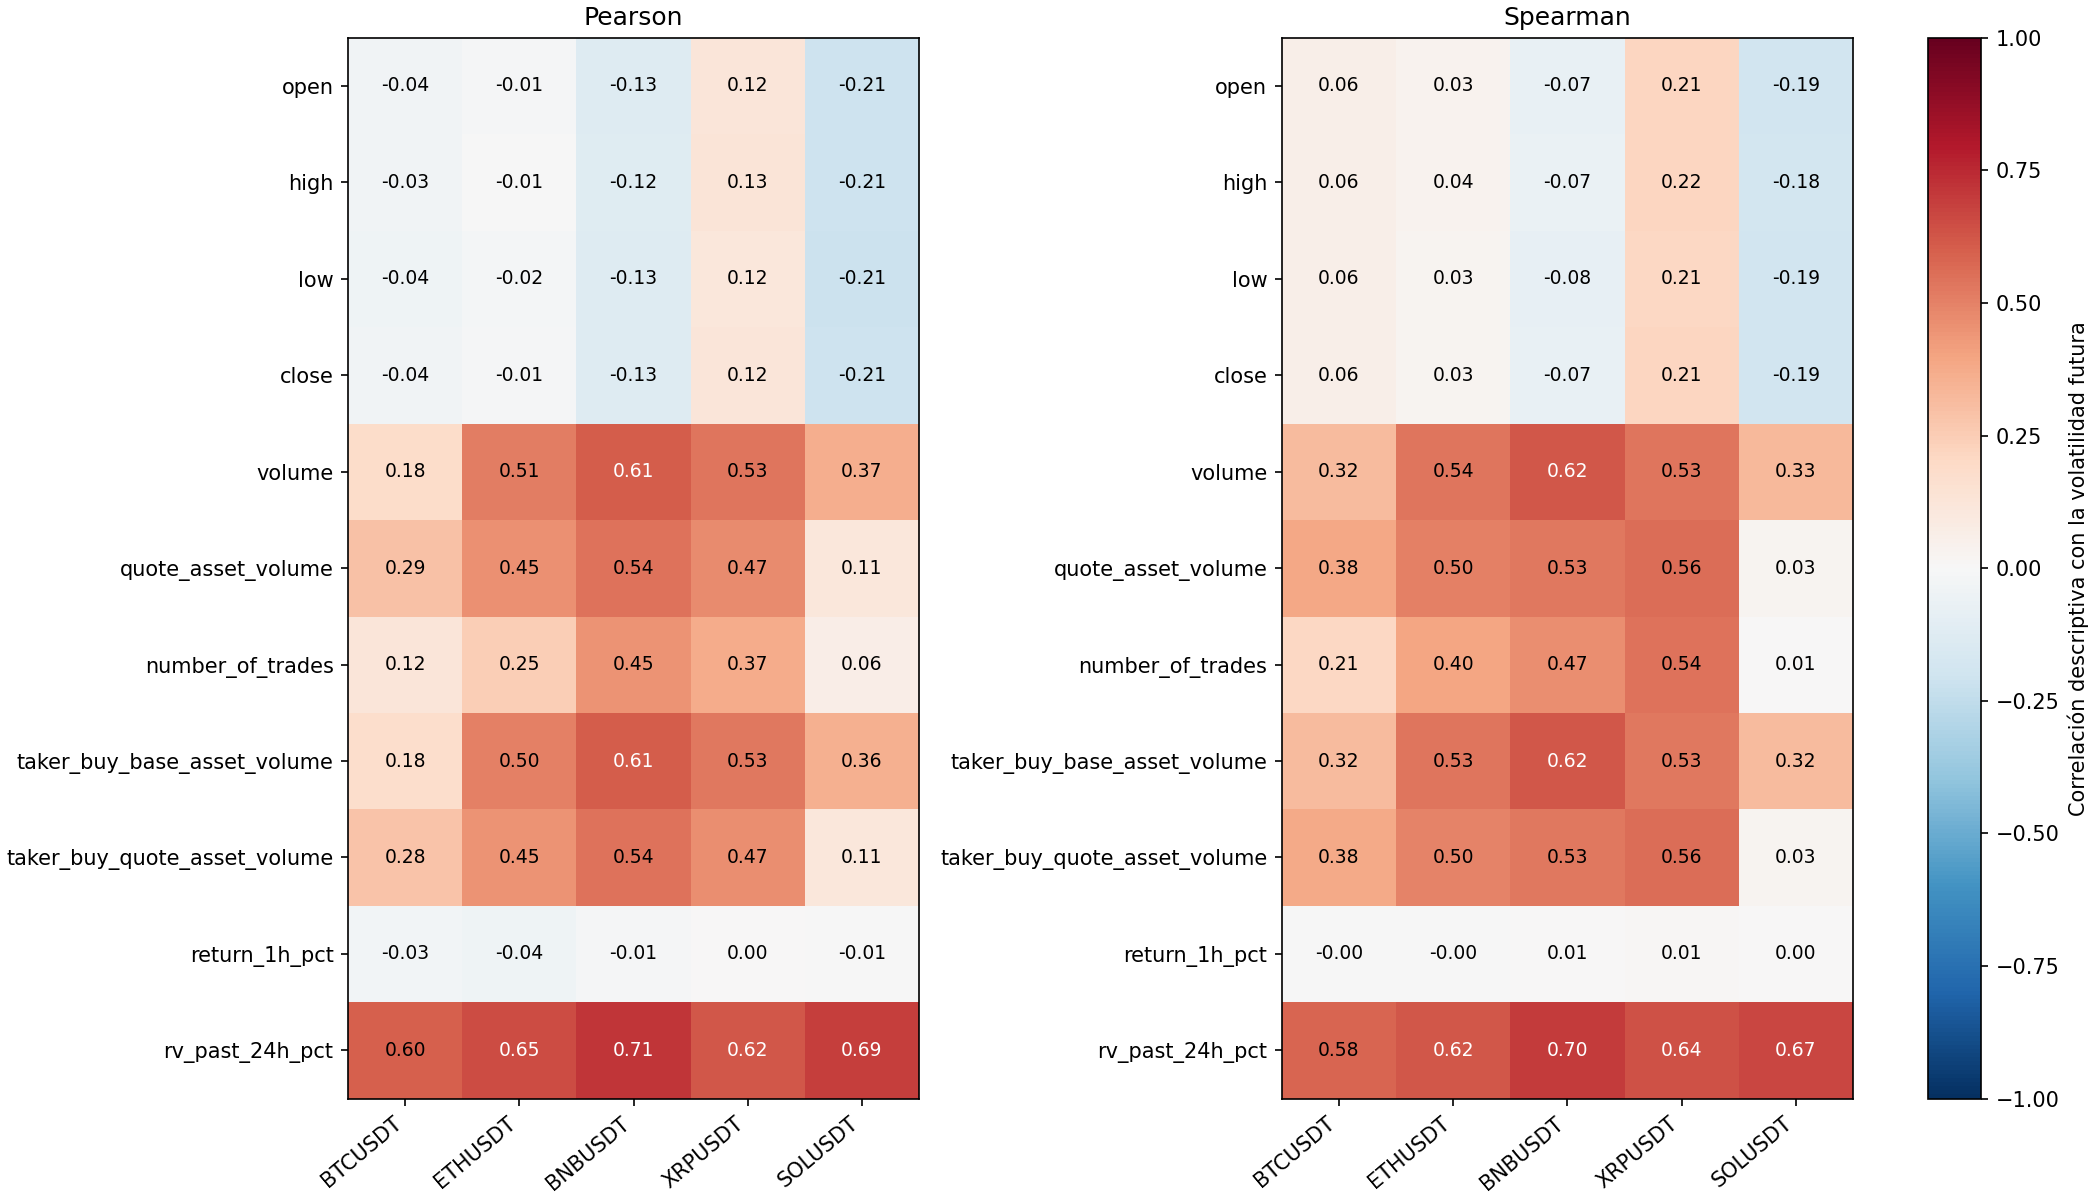

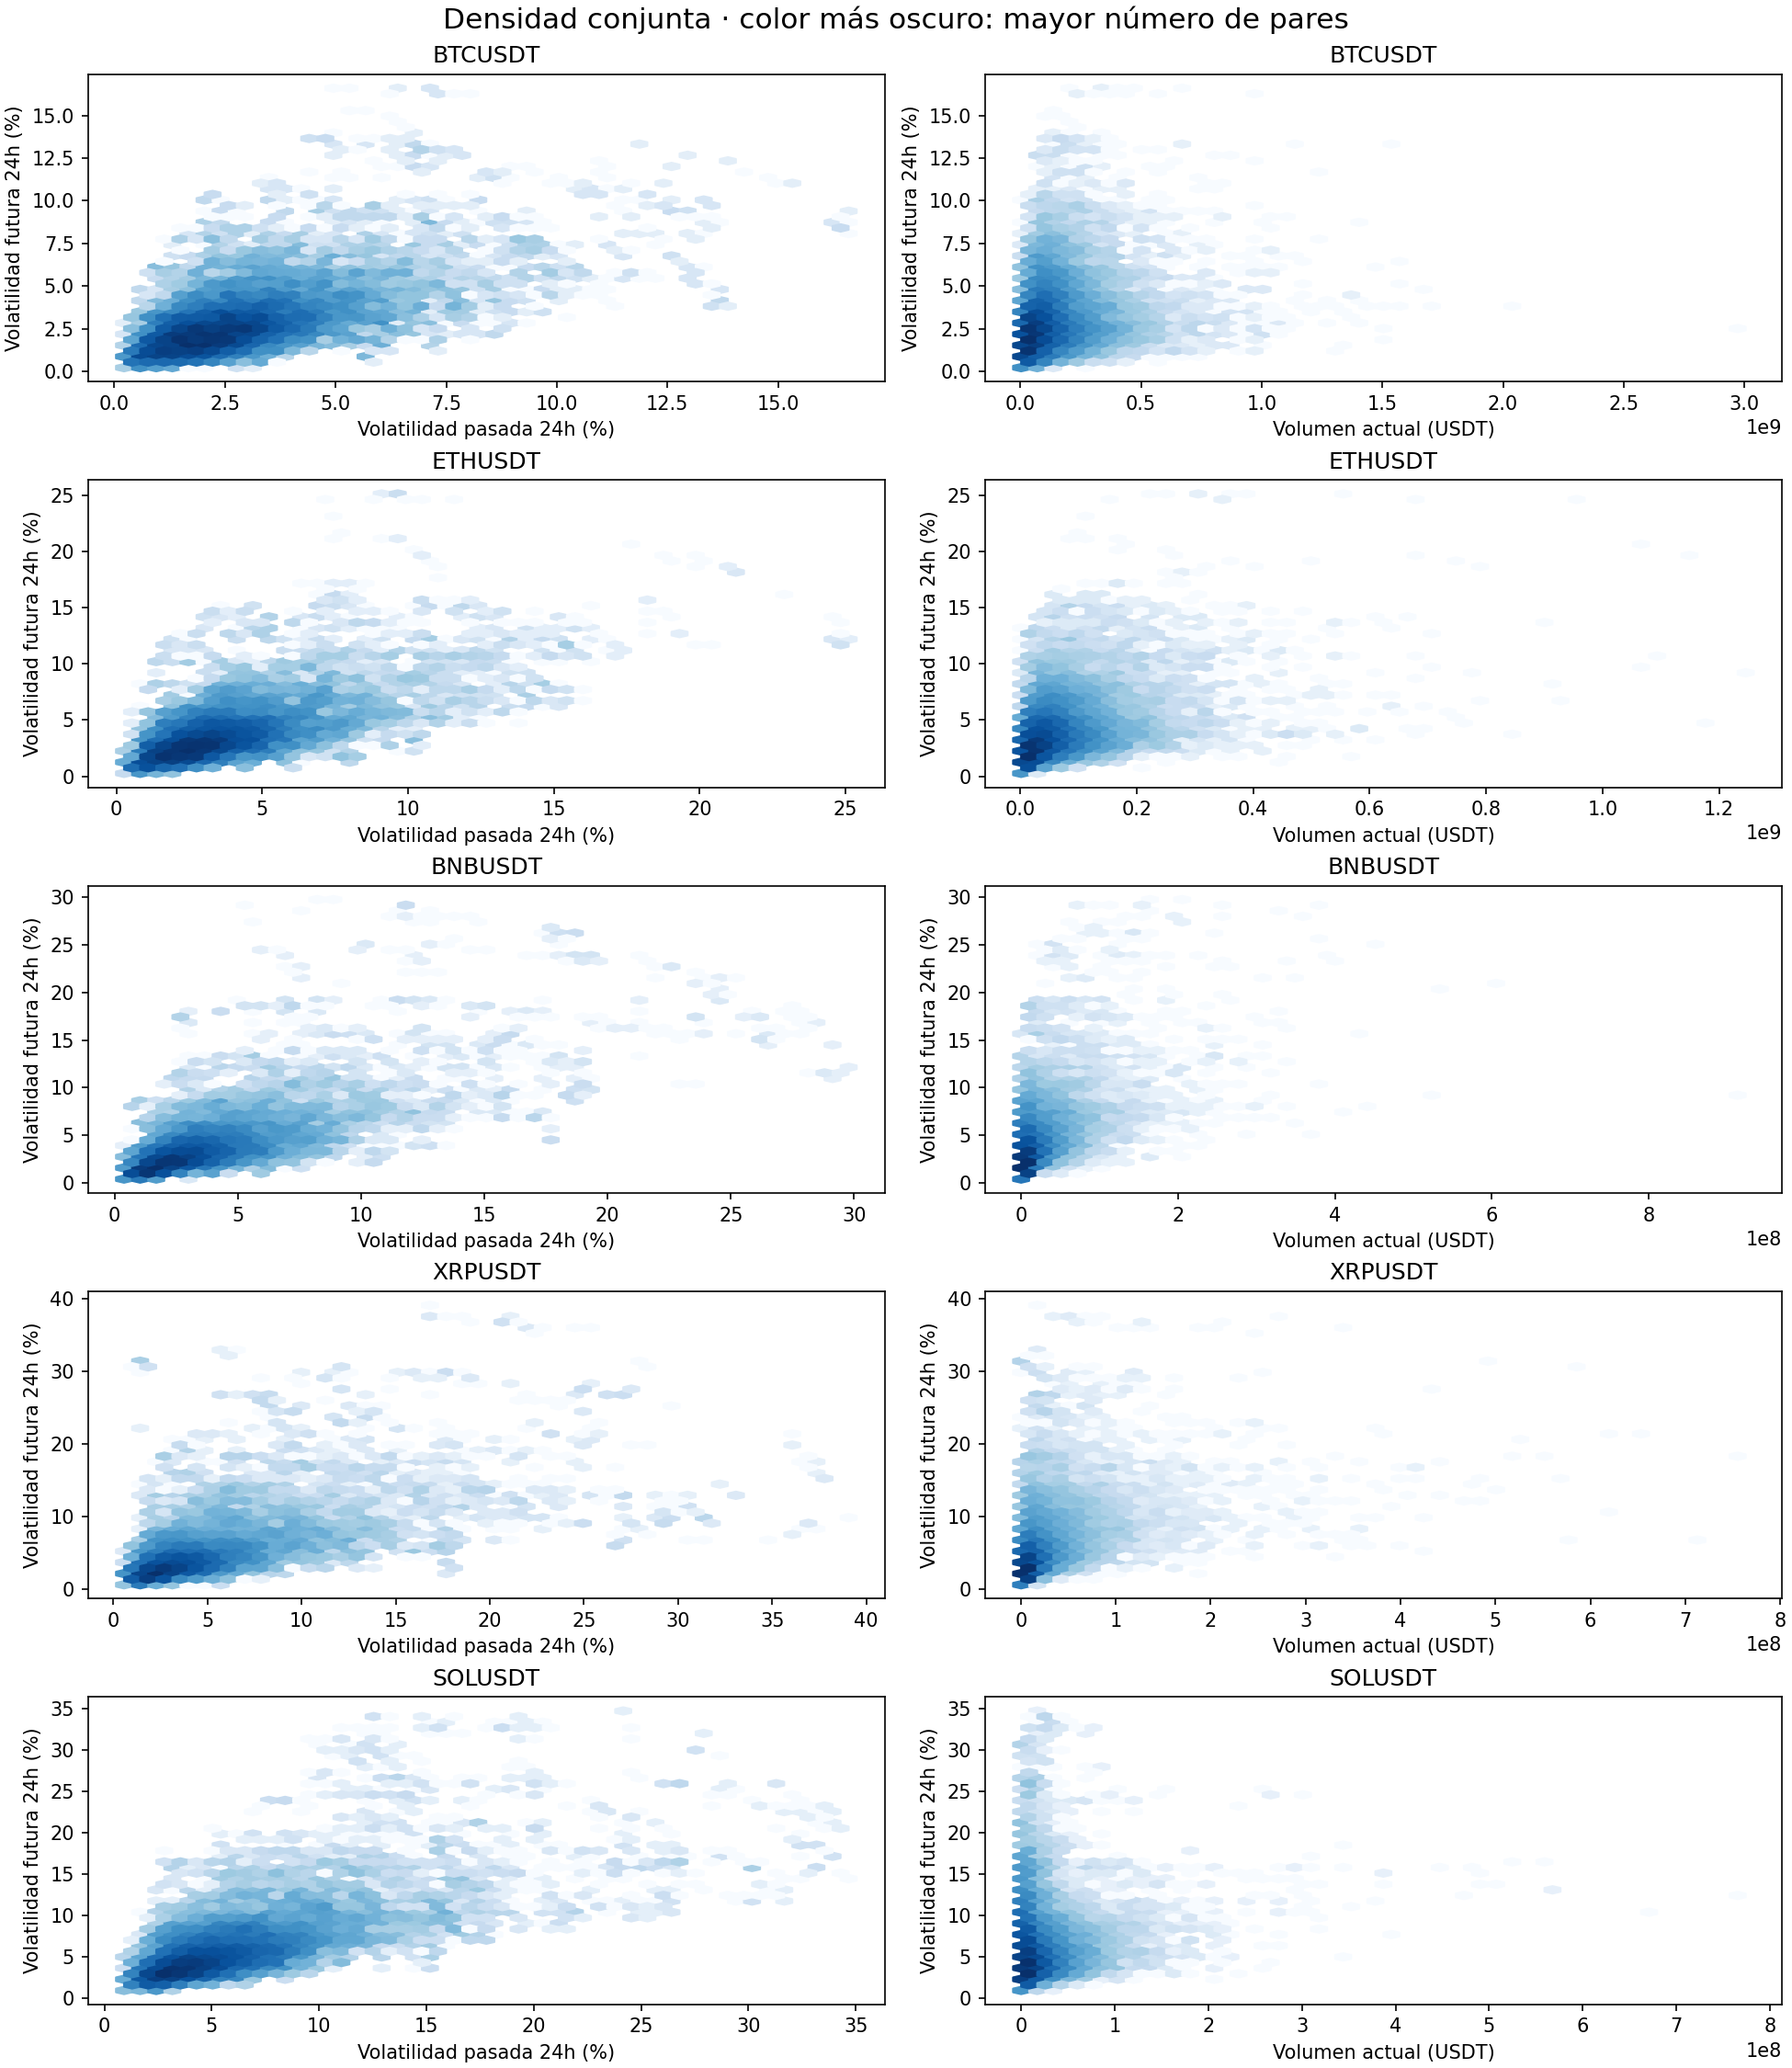

,symbol,observed,valid,boundary,missing_window,irregular_window
0,BTCUSDT,42833,42539,24,240,30
1,ETHUSDT,42833,42539,24,240,30
2,BNBUSDT,42833,42539,24,240,30
3,XRPUSDT,42833,42564,24,240,5
4,SOLUSDT,42833,42564,24,240,5


,symbol,n,min,q1,median,mean,q3,p95,p99,max,...,excess_kurtosis,zero,lower,upper,iqr_flagged,iqr_percent,log_skew,log_excess_kurtosis,acf_1h,acf_24h
0,BTCUSDT,42539,0.219194,1.656197,2.423885,2.752185,3.374404,5.909474,8.814840,16.597123,...,7.100681,0,-0.921113,5.951714,2058,4.837913,-0.279573,0.564254,0.989654,0.595054
1,ETHUSDT,42539,0.265894,2.169481,3.094506,3.563948,4.388486,7.548949,12.042313,25.105754,...,8.878070,0,-1.159026,7.716993,1965,4.619291,-0.137725,0.424703,0.990802,0.649831
2,BNBUSDT,42539,0.387853,1.856326,2.790285,3.434189,4.147656,7.918066,13.660451,29.777706,...,17.727180,0,-1.580670,7.584652,2429,5.710054,0.175922,0.258910,0.993560,0.711243
3,XRPUSDT,42564,0.561085,2.303341,3.364980,4.367836,5.068242,10.959860,18.607843,39.064689,...,15.266036,0,-1.844011,9.215594,3261,7.661404,0.454391,0.357605,0.991477,0.624981
4,SOLUSDT,42564,0.916743,3.404848,4.785216,5.699567,6.873127,12.308931,19.620708,34.665509,...,11.011773,0,-1.797571,12.075546,2246,5.276760,0.303921,0.279816,0.992493,0.688746


,symbol,predictor,n,pearson,spearman
0,BTCUSDT,open,42539,-0.035588,0.058266
1,BTCUSDT,high,42539,-0.032909,0.060506
2,BTCUSDT,low,42539,-0.039074,0.055666
3,BTCUSDT,close,42539,-0.035947,0.058160
4,BTCUSDT,volume,42539,0.181530,0.319609
5,BTCUSDT,quote_asset_volume,42539,0.291183,0.383556
6,BTCUSDT,number_of_trades,42539,0.121942,0.209158
7,BTCUSDT,taker_buy_base_asset_volume,42539,0.177375,0.318316
8,BTCUSDT,taker_buy_quote_asset_volume,42539,0.284027,0.381517
9,BTCUSDT,return_1h_pct,42527,-0.027658,-0.000510


,symbol,strict_n,relaxed_n,strict_mean,relaxed_mean,strict_p99,relaxed_p99,strict_max,relaxed_max
0,BTCUSDT,42539,42569,2.752185,2.752214,8.814840,8.814268,16.597123,16.597123
1,ETHUSDT,42539,42569,3.563948,3.563351,12.042313,12.037623,25.105754,25.105754
2,BNBUSDT,42539,42569,3.434189,3.433967,13.660451,13.662016,29.777706,29.777706
3,XRPUSDT,42564,42569,4.367836,4.368367,18.607843,18.605748,39.064689,39.064689
4,SOLUSDT,42564,42569,5.699567,5.699833,19.620708,19.620460,34.665509,34.665509


In [2]:
from IPython.display import display, Image
for name in ['distribution', 'time', 'correlations', 'relations']:
    display(Image(filename=str(FIGURES / f'eda_target_{name}.png')))
for name in ['coverage', 'summary', 'correlations', 'sensitivity']:
    display(pd.read_csv(TABLES / f'eda_target_{name}.csv'))